2026-04-16 13:45:39.275 | WARNING  | qpdk:<module>:30 - QPDK models could not be loaded (No module named 'jaxellip'). Ensure dependencies are installed with `pip install qpdk[models]`.


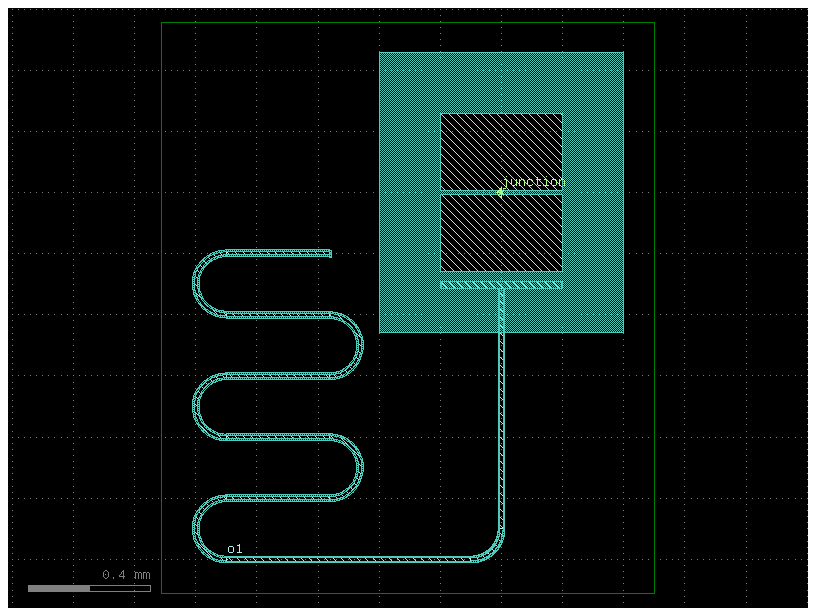

In [1]:
import gdsfactory as gf
from qpdk import PDK, cells
from qpdk.cells.helpers import apply_additive_metals
from qpdk.tech import LAYER

PDK.activate()


@gf.cell
def transmon_component() -> gf.Component:
    """Create a qubit with resonator layout."""
    c = gf.Component()

    ref = c << cells.double_pad_transmon_with_resonator(
        qubit="double_pad_transmon_with_bbox",
        resonator_length=5000.0,
        resonator_meanders=5,
        qubit_rotation=90,
    )
    c.add_ports(ref.ports)

    # Add simulation area around the component
    c.kdb_cell.shapes(LAYER.SIM_AREA).insert(c.bbox().enlarged(100, 100))

    return c


component = transmon_component()
_c = component.copy()
_c.draw_ports()
_c

### Inspect raw layers and apply additive metals

In [2]:
from gsim.common.polygon_utils import inspect_layers

# inspect_layers(component, filename="transmon_raw_layers.png")

# Apply additive metals processing (QPDK-specific step)
processed = apply_additive_metals(component.copy())

# inspect_layers(processed, filename="transmon_processed_layers.png")

### Convert QPDK etch layers to conductor geometry

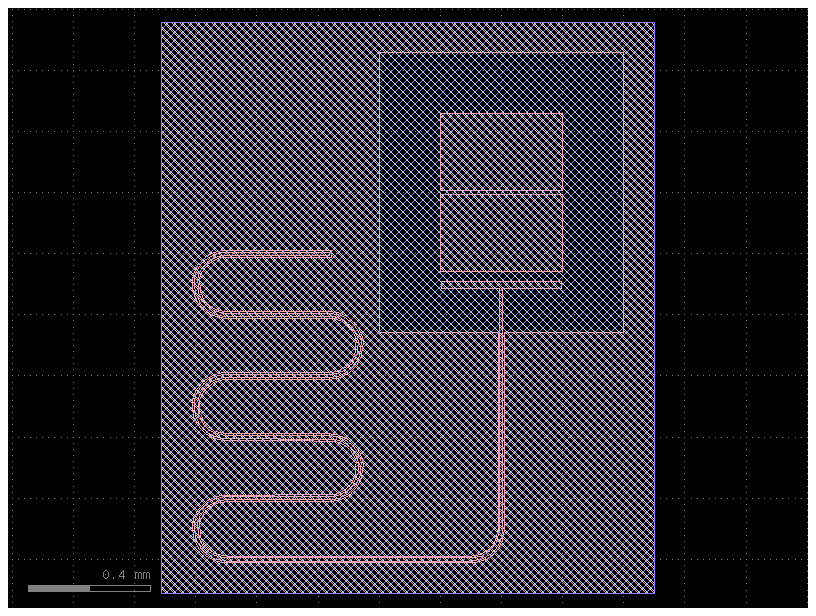

In [ ]:
import warnings

import klayout.db as kdb
from qpdk.tech import LAYER as QPDK_LAYER

from gsim.common.polygon_utils import decimate

sim_area_layer = (QPDK_LAYER.SIM_AREA[0], QPDK_LAYER.SIM_AREA[1])
etch_layer = (QPDK_LAYER.M1_ETCH[0], QPDK_LAYER.M1_ETCH[1])

CPW_LAYERS = {"SUBSTRATE": (1, 0), "SUPERCONDUCTOR": (2, 0), "VACUUM": (3, 0)}

layout = processed.kdb_cell.layout()
sim_region = kdb.Region(
    processed.kdb_cell.begin_shapes_rec(layout.layer(*sim_area_layer))
)
etch_region = kdb.Region(processed.kdb_cell.begin_shapes_rec(layout.layer(*etch_layer)))

etch_polys = decimate(list(etch_region.each()))
etch_region = kdb.Region()
for poly in etch_polys:
    etch_region.insert(poly)

if sim_region.is_empty():
    warnings.warn("No polygons found on SIM_AREA", stacklevel=2)
if etch_region.is_empty():
    warnings.warn("No polygons found on M1_ETCH", stacklevel=2)

conductor_region = sim_region - etch_region

etched = gf.Component("etched_component")
el = etched.kdb_cell.layout()
for name, region in [
    ("SUPERCONDUCTOR", conductor_region),
    ("SUBSTRATE", sim_region),
    ("VACUUM", sim_region),
]:
    idx = el.layer(*CPW_LAYERS[name])
    etched.kdb_cell.shapes(idx).insert(region)

for port in processed.ports:
    etched.add_port(name=port.name, port=port)

# inspect_layers(etched, filename="transmon_etched_layers.png")
etched

### Configure Simulation

In [4]:
from gsim.common.stack import Layer, LayerStack
from gsim.common.stack.materials import MATERIALS_DB
from gsim.palace import DrivenSim

# Build a CPW stack matching the etched component layers
substrate_thickness = 500
vacuum_thickness = 500

stack = LayerStack(pdk_name="qpdk")
stack.layers["SUBSTRATE"] = Layer(
    name="SUBSTRATE",
    gds_layer=(1, 0),
    zmin=0.0,
    zmax=substrate_thickness,
    thickness=substrate_thickness,
    material="sapphire",
    layer_type="dielectric",
)
stack.layers["SUPERCONDUCTOR"] = Layer(
    name="SUPERCONDUCTOR",
    gds_layer=(2, 0),
    zmin=substrate_thickness,
    zmax=substrate_thickness,
    thickness=0,
    material="aluminum",
    layer_type="conductor",
)
stack.layers["VACUUM"] = Layer(
    name="VACUUM",
    gds_layer=(3, 0),
    zmin=substrate_thickness,
    zmax=substrate_thickness + vacuum_thickness,
    thickness=vacuum_thickness,
    material="vacuum",
    layer_type="dielectric",
)
stack.dielectrics = [
    {
        "name": "substrate",
        "zmin": 0.0,
        "zmax": substrate_thickness,
        "material": "sapphire",
    },
    {
        "name": "vacuum",
        "zmin": substrate_thickness,
        "zmax": substrate_thickness + vacuum_thickness,
        "material": "vacuum",
    },
]
stack.materials = {
    "sapphire": MATERIALS_DB["sapphire"].to_dict(),
    "aluminum": MATERIALS_DB["aluminum"].to_dict(),
    "vacuum": MATERIALS_DB["vacuum"].to_dict(),
}

sim = DrivenSim()
sim.set_geometry(etched)
sim.set_stack(stack)

### Configure eigenmode simulation

The junction port is modelled as a lumped element with a 10 nH inductance.

In [5]:
# Junction port with 10 nH inductance
sim.add_port("junction", layer="SUPERCONDUCTOR", length=5.0, inductance=10e-9)

# CPW feed ports
sim.add_cpw_port("o1", layer="SUPERCONDUCTOR", s_width=10.0, gap_width=6.0, length=5.0)

sim.set_driven(fmin=7.75e9, fmax=7.8e9, num_points=100)

### Mesh and run

In [6]:
sim.set_output_dir("./sim_qpdk_qubit_resonator")
sim.mesh(preset="graded", margin=0)

Mesh Summary
Dimensions: 1610.9 x 1868.5 x 1000.0 µm
Nodes:      33,480
Elements:   224,514
Tetrahedra: 169,275
Edge length: 0.00 - 442.01 µm
Quality:    0.602 (min: 0.000)
SICN:       0.659 (all valid)
----------------------------------------
Volumes (2):
  - sapphire [1]
  - vacuum [2]
Surfaces (7):
  - SUPERCONDUCTOR_pec [3]
  - P1 [4]
  - P2_E0 [5]
  - P2_E1 [6]
  - sapphire__None [7]
  - sapphire__vacuum [8]
  - vacuum__None [9]
----------------------------------------
Mesh:   sim_qpdk_qubit_resonator/palace.msh

In [7]:
sim.plot_mesh(
    style="solid",
    interactive=True,
    transparent_groups=["vacuum__None", "sapphire__None"],
)

Widget(value='<iframe src="http://localhost:44923/index.html?ui=P_0x75dfc88af5c0_0&reconnect=auto" class="pyvi…

In [8]:
sim.write_config()
results = sim.run_local()

RuntimeError: Palace simulation failed with return code 1

Stdout:
>> /usr/lib64/mpich/bin/mpirun -n 1 /opt/palace/bin/palace-x86_64.bin config.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/

Git changeset ID: v0.14.0-305-g51d61b03
Running with 1 MPI process, 1 OpenMP thread
Device configuration: omp,cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 9599 duplicate vertices for interior boundaries in the mesh
Added 23235 duplicate boundary elements for interior boundaries in the mesh
Finished partitioning mesh into 1 subdomain

Characteristic length and time scales:
 L₀ = 1.868e-03 m, t₀ = 6.233e-03 ns

Mesh curvature order: 1
Mesh bounding box:
 (Xmin, Ymin, Zmin) = (-1.111e-03, -1.311e-03, +0.000e+00) m
 (Xmax, Ymax, Zmax) = (+5.000e-04, +5.575e-04, +1.000e-03) m

Parallel Mesh Stats:

          